# パチンコユーザーの微分方程式モデリング
**ModelingToolkit.jl v11 / Turing.jl v0.43 / Julia 1.12 対応版**

ModelingToolkitやTuringなどのJuliaの道具がマーケティング的な発想と分析にどのように活用できるのかを試し、多くの人に利用してもらうことでユーザーの幅を広げることを目的としている。ModelingToolkitは「微分方程式を記号的に扱う」パッケージで、TuringはMCMCという乱数発生アルゴリズムを利用し「パラメータを推定するパッケージ」という程度の理解でよい。

私の興味は産業の隆盛（ブーム）と衰退のメカニズムであり、ここでは具体例として「パチンコ」を取り上げる。1994年以降のパチンコユーザー調査を利用する。データは日本生産性本部の「レジャー白書」を参照している。

In [2]:
using CSV, DataFrames, StatsPlots
using ModelingToolkit
using ModelingToolkit: t_nounits as t, D_nounits as D
using DifferentialEquations
using DataInterpolations, ForwardDiff
using Turing, Distributions, Optim
default(size=(600,400), lw=2)

In [3]:
# Plots 日本語フォント設定
ENV["GKS_ENCODING"] = "utf8"
gr(fontfamily="PlemolJP-Text")
default(
  fontfamily="PlemolJP-Text",
  guidefontsize=11,
  tickfontsize=8,
  legendfontsize=8,
  margin=5Plots.mm,
  annotationfontsize=8
)

In [4]:
df = CSV.read("pdata2024.csv", DataFrame)
rename!(df, "パチンコユーザー(千人）" => :P_user,
            "人口推移（千人）"       => :V_population,
            "生産年齢人口（千人）"   => :V_working)
last(df, 5)

Row,Year,P_user,V_population,V_working,備考
,Int64,Int64?,Float64,Int64,String?
1,2019,8900,126633.0,74600,missing
2,2020,7100,126261.0,74100,国勢調査
3,2021,7200,1.25682e5,74000,missing
4,2022,7700,125125.0,73980,missing
5,2023,missing,1.24517e5,73950,総務省推計（59.5%）


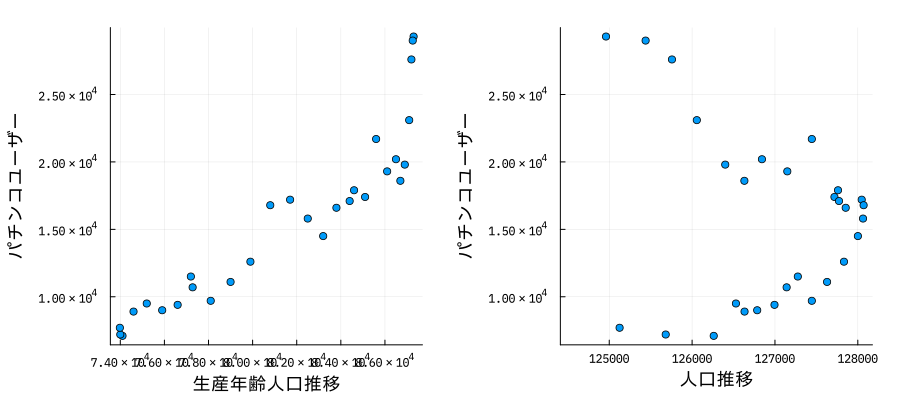

In [5]:
p1 = @df df scatter(:V_working, :P_user, ylabel="パチンコユーザー",xlabel="生産年齢人口推移")
p2 = @df df scatter(:V_population, :P_user, ylabel="パチンコユーザー", xlabel="人口推移")
fig = plot(p1,p2, size=(900,400),label="") ; savefig(fig, "人口推移×パチンコプレイヤー.png")
fig

1994年のプレイヤー人口2930万人（29,300千人）から持続的に減少し、2016年以降は1000万人以下が常態となっている。プレイヤーの減少はどこまで続くのだろうか？

（注：データの単位は千人。2023年はユーザー調査データなし。）

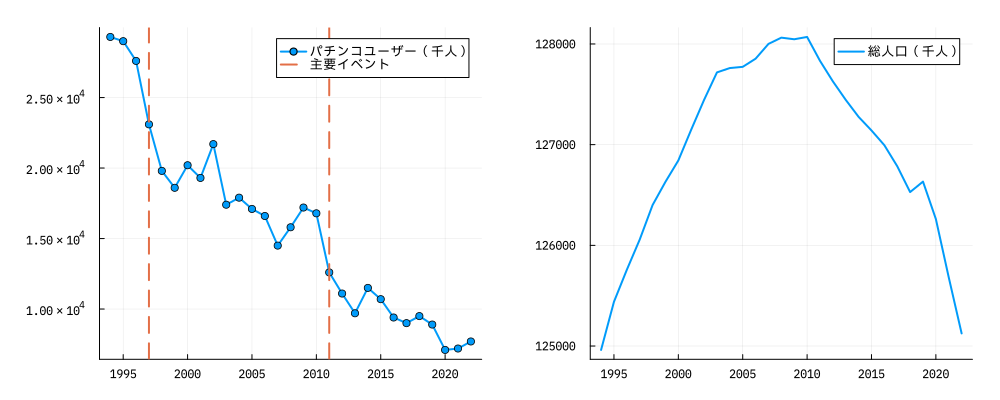

In [6]:
dx = df[:, [:Year, :P_user, :V_population, :V_working]] |> dropmissing
Pu = Float64.(dx.P_user)
Vu = Float64.(dx.V_population) 
Wu = Float64.(dx.V_working)  # 総人口（千人）
year = dx.Year
n_data = length(Pu)   # 29点（1994〜2022年）

p1 = plot(year, Pu, label="パチンコユーザー（千人）", marker=:circle)
vline!(p1, [1997, 2011], ls=:dash, label="主要イベント")
p2 = plot(year, Vu, label="総人口（千人）")
plot(p1, p2, size=(1000,400))

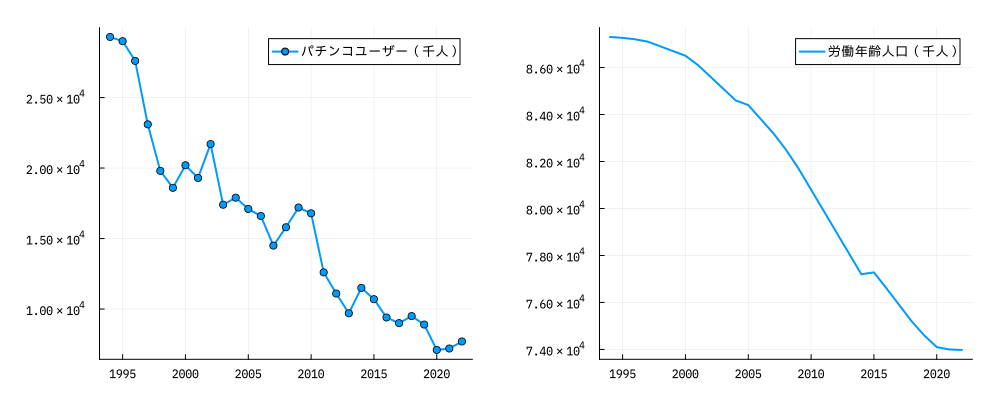

In [7]:
p1 = plot(year, Pu, label="パチンコユーザー（千人）", marker=:circle)
p2 = plot(year, Wu, label="労働年齢人口（千人）")
plot(p1, p2, size=(1000,400))

### 数学は詳しくないので間違いが含まれていると思う。寛大な心でご指摘願いたい。

人類はパチンコプレイヤー（P）とパチンコをやらない人「ノンプレイヤー」（N）に二分される。プレイヤーはある一定の確率でノンプレイヤーになるし、ノンプレイヤーも一定の確率でプレイヤーになる。この関係を微分方程式で記述する。

人口の変動分 dV(t) は死亡／誕生による差分なので、いずれもノンユーザーとしてモデルに組み込む。

### パラメータ・変数の定義

| 記号 | 意味 |
|------|------|
| `e` | パチンコ遊戯へのエントリー係数 |
| `r` | パチンコ遊戯を中断（retire）する係数 |
| `b` | 人口変動（誕生・死亡）による定数変化係数 |
| `P(t)` | パチンコユーザー（千人）|
| `N(t)` | ノンユーザー（千人）|
| `V(t)` | 人口全体 N + P（千人）|

In [8]:
# 基本モデル（人口変動 b を定数とする）
@parameters b=0.0 e=0.03 r=0.1
@variables P(t) N(t) V(t)

eqs_const = [
    D(P) ~ e * (V - P) - r * P,
    N    ~ V - P,                  # 保存則 V = P + N より代数方程式
    D(V) ~ b
]

@named sys_const = ODESystem(eqs_const, t, [P, N, V], [b, e, r])
sys_const = structural_simplify(sys_const)

Model sys_const:
Equations (2):
  2 standard: see equations(sys_const)
Unknowns (2): see unknowns(sys_const)
  V(t)
  P(t)
Parameters (3): see parameters(sys_const)
  b
  e
  r
Observed (1): see observed(sys_const)

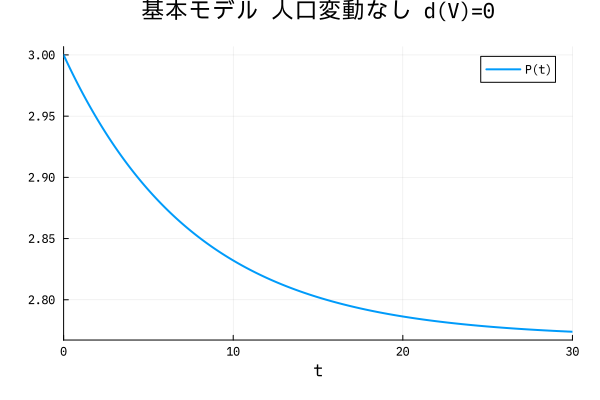

In [9]:
ps_const = [sys_const.P => 3.0, sys_const.V => 12.0,
            sys_const.b => 0.0, sys_const.e => 0.03, sys_const.r => 0.1]
prob_const = ODEProblem(sys_const, ps_const, (0.0, 30.0))
sol_const = solve(prob_const)
plot(sol_const, idxs=[sys_const.P], label="P(t)", title="基本モデル 人口変動なし d(V)=0")

## データ駆動の人口変動モデル

実際の人口データを補間して `dV/dt` をデータから直接得る。`DataInterpolations.jl` で2次補間を行い、`ForwardDiff.jl` で数値微分する。

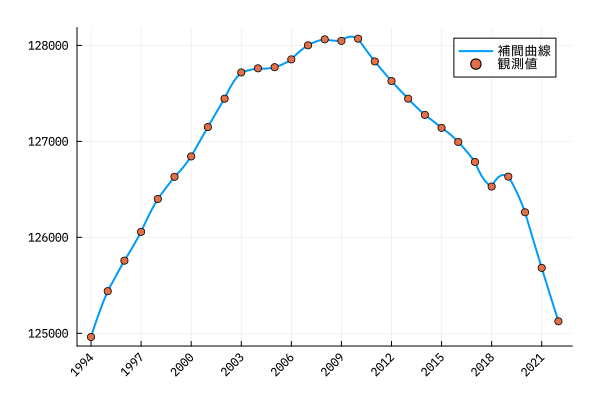

In [10]:
using DataInterpolations: ExtrapolationType

vu_d = QuadraticInterpolation(Vu, 0.0:Float64(n_data - 1);
                               extrapolation_right = ExtrapolationType.Constant)

ts_plot = 0:0.2:(n_data-1)
plot(ts_plot, vu_d.(ts_plot), label="補間曲線", xticks=(0:3:(n_data-1), year[1:3:end]), xrotation=45)
scatter!(0:(n_data-1), Vu, label="観測値")

In [11]:
dvu(τ) = ForwardDiff.gradient(x -> vu_d(x[1]), [τ])[1]
@register_symbolic dvu(t)

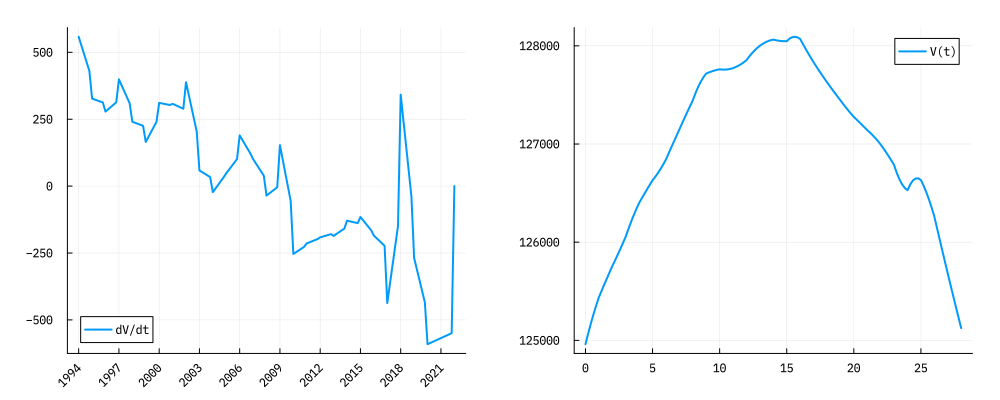

In [12]:
d_vu = [dvu(τ) for τ in ts_plot]
p1 = plot(ts_plot, d_vu, label="dV/dt", xticks=(0:3:(n_data-1), year[1:3:end]), xrotation=45)
p2 = plot(ts_plot, vu_d.(ts_plot), label="V(t)")
plot(p1, p2, size=(1000,400))

## 人口変動モデル

`dvu(t)` を `D(V)` に使うモデルに更新する。`ODESystem` + `structural_simplify` でシンボリックコンパイルを行う。

In [13]:
@parameters e r
@variables P(t) N(t) V(t)

eqs_dvu = [
    D(P) ~ e * (V - P) - r * P,
    N    ~ V - P,
    D(V) ~ dvu(t)
]

@named sys = ODESystem(eqs_dvu, t, [P, N, V], [e, r])
sys = structural_simplify(sys)

Model sys:
Equations (2):
  2 standard: see equations(sys)
Unknowns (2): see unknowns(sys)
  V(t)
  P(t)
Parameters (2): see parameters(sys)
  e
  r
Observed (1): see observed(sys)

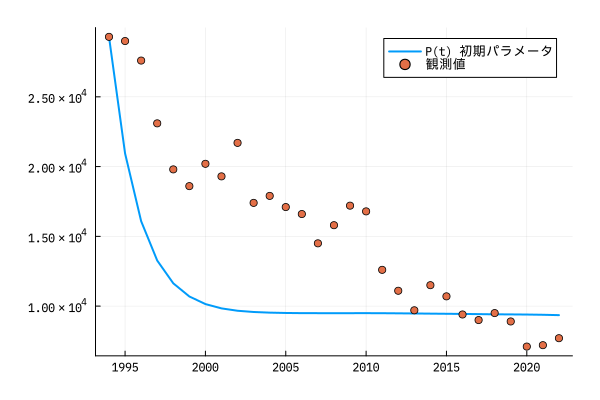

In [14]:
u0 = [sys.P => Pu[1], sys.V => Vu[1]]
ps = [sys.e => 0.04, sys.r => 0.5]
tspan = (0.0, Float64(n_data - 1))

probv = ODEProblem(sys, vcat(u0, ps), tspan)
solv = solve(probv, saveat=collect(0.0:Float64(n_data-1)))

plot(year, solv[sys.P], label="P(t) 初期パラメータ")
scatter!(year, Pu, label="観測値")

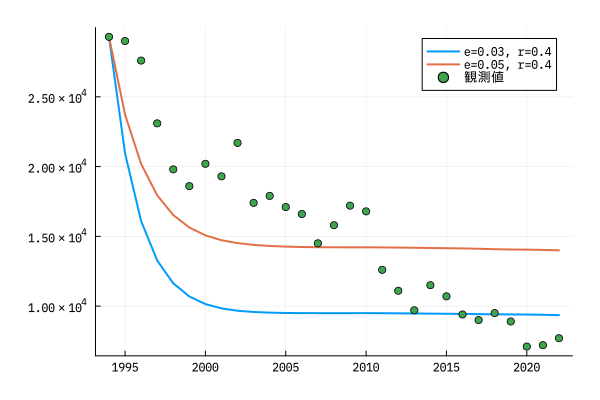

In [15]:
# remake でパラメータを変えて比較
rprob = remake(probv; p=[sys.e => 0.05, sys.r => 0.4])
rsolv = solve(rprob, saveat=collect(0.0:Float64(n_data-1)))

plot(year, solv[sys.P], label="e=0.03, r=0.4")
plot!(year, rsolv[sys.P], label="e=0.05, r=0.4")
scatter!(year, Pu, label="観測値")

# Turing.jl によるパラメータ推定

Turing.jl v0.43 の NUTS サンプラーを使って `e`（エントリー係数）と `r`（リタイア係数）をベイズ推定する。

- **NUTS**（No-U-Turn Sampler）: HMC の適応版。効率的な事後分布のサンプリング
- `remake` でパラメータを差し替えて ODE を再解法する
- `TDist(1)` の切断分布を事前分布に使用（裾の重い分布で外れ値に頑健）

In [16]:
@model function findprm(prob, sys, xs; n=length(xs), ts=(0.0, Float64(n-1)))
    entry  ~ truncated(TDist(1), 1e-5, 0.1) 
    retire ~ truncated(TDist(1), 1e-5, 0.1)
    s ~ InverseGamma(2, 3)

    _prob = remake(prob; tspan=ts, p=[sys.e => entry, sys.r => retire])
    solv = solve(_prob, saveat=collect(ts[1]:ts[2]))

    # 解法失敗時は確率 -Inf を返す
    if length(solv[sys.P]) < n
        Turing.@addlogprob! -Inf
        return
    end

    for i in 1:n
        xs[i] ~ Normal(solv[sys.P][i], s)
    end
end

findprm (generic function with 2 methods)

In [17]:
model_full = findprm(probv, sys, Pu)
@time chain_full = sample(model_full, NUTS(), 3000)
describe(chain_full)

┌ Info: Found initial step size
└   ϵ = 1.220703125e-5
Sampling: 100%|█████████████████████████████████████████| Time: 0:07:34


495.816366 seconds (1.60 G allocations: 75.087 GiB, 3.02% gc time, 8.14% compilation time: 1% of which was recompilation)
Chains MCMC chain (3000×17×1 Array{Float64, 3}):

Iterations        = 1001:1:4000
Number of chains  = 1
Samples per chain = 3000
Wall duration     = 483.49 seconds
Compute duration  = 483.49 seconds
parameters        = entry, retire, s
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, logprior, loglikelihood, logjoint

Summary Statistics

  parameters        mean        std      mcse   ess_bulk   ess_tail      rhat  ⋯
      Symbol     Float64    Float64   Float64    Float64    Float64   Float64  ⋯

       entry      0.0020     0.0013    0.0001   211.4311    88.2525    1.0037  ⋯
      retire      0.0623     0.0087    0.0007   199.6270    82.5721    1.0031  ⋯
           s   1737.3489   228.0783    8.2916   782.1396   93

In [18]:
# ---- WAIC 計算ユーティリティ ----
"""
    calc_waic(P_mat, obs, s_vec) -> Float64

WAIC（Widely Applicable Information Criterion）を計算する。
- P_mat : n_obs × n_samp の ODE 解行列
- obs   : 長さ n_obs の観測ベクトル
- s_vec : 長さ n_samp の σ サンプル（AbstractVector 可）
"""
function calc_waic(P_mat::Matrix, obs::Vector, s_vec)
    n_obs, n_samp = size(P_mat)
    ss = collect(s_vec)[1:n_samp]
    log_lik = [logpdf(Normal(P_mat[i, j], ss[j]), obs[i])
                for i in 1:n_obs, j in 1:n_samp]
    lppd   = sum(let c = log_lik[i, :]
                     mx = maximum(c)
                     mx + log(mean(exp.(c .- mx)))
                 end for i in 1:n_obs)
    p_waic = sum(var(log_lik[i, :]) for i in 1:n_obs)
    round(-2 * (lppd - p_waic), digits=1)
end

calc_waic

param_mean = (e = 0.0019790847617861588, r = 0.06225614306667599)
waic_full = 519.6


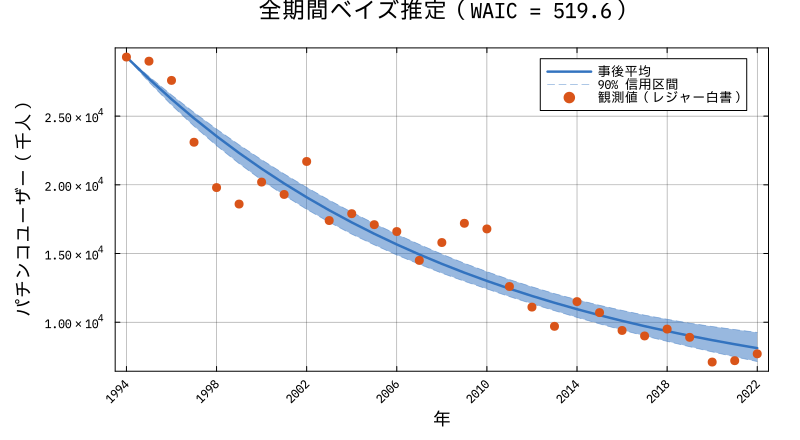

In [21]:
param_full = get(chain_full, [:entry, :retire, :s])
param_mean = (e = mean(param_full.entry), r = mean(param_full.retire))
@show param_mean

t_obs = collect(0.0:Float64(n_data - 1))

# 全 MCMC サンプルで ODE を解いて P の軌跡と s を収集
P_trajectories = Vector{Float64}[]
s_valid        = Float64[]
for i in eachindex(param_full.entry)
    sol_i = solve(remake(probv; p=[sys.e => param_full.entry[i], sys.r => param_full.retire[i]]),
                  saveat=t_obs)
    length(sol_i[sys.P]) == n_data || continue
    push!(P_trajectories, sol_i[sys.P])
    push!(s_valid, param_full.s[i])
end
P_mat  = hcat(P_trajectories...)

# 90% 信用区間
P_lo = [quantile(P_mat[j, :], 0.05) for j in 1:n_data]
P_hi = [quantile(P_mat[j, :], 0.95) for j in 1:n_data]

# WAIC
waic_full = calc_waic(P_mat, Pu, s_valid)
@show waic_full

# 事後平均解
rsol_full    = solve(remake(probv; p=[sys.e => param_mean.e, sys.r => param_mean.r]),
                     saveat=t_obs)
P_mean_curve = rsol_full[sys.P]

# ---- プロット ----
c_line = RGB(0.20, 0.45, 0.75)
c_obs  = RGB(0.85, 0.33, 0.10)

plot(year, P_mean_curve;
    ribbon     = (P_mean_curve .- P_lo, P_hi .- P_mean_curve),
    fillcolor  = c_line, fillalpha = 0.5,
    lc = c_line, lw = 2.5,
    label      = "事後平均",
    xlabel     = "年",
    ylabel     = "パチンコユーザー（千人）",
    title      = "全期間ベイズ推定（WAIC = $(waic_full)）",
    size       = (800, 440),
    xlims      = (year[1]-0.5, year[end]+0.5),
    xticks     = (1994:4:2022, string.(1994:4:2022)),
    xrotation  = 45,
    grid       = true, gridalpha = 0.25,
    framestyle = :box,
    legend     = :topright,
    bg         = :white,
    margin     = 6Plots.mm,
)
plot!(year, P_lo; lc = c_line, lw = 0.8, ls = :dash, alpha = 0.5, label = "90% 信用区間")
plot!(year, P_hi; lc = c_line, lw = 0.8, ls = :dash, alpha = 0.5, label = "")
scatter!(year, Pu; mc = c_obs, ms = 5, msw = 0, label = "観測値（レジャー白書）")

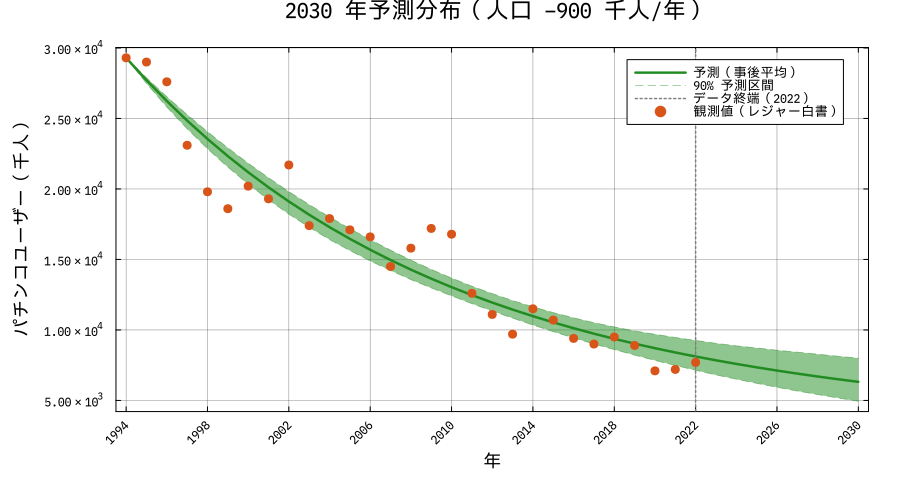

In [22]:
# ---- 2030 年予測分布（人口 -900 千人/年 外挿）----

# 外挿付き dV/dt：2023 年以降は -900 千人/年 で固定
dvu_ext(τ) = τ <= Float64(n_data - 1) ?
    ForwardDiff.gradient(x -> vu_d(x[1]), [τ])[1] : -900.0
@register_symbolic dvu_ext(t)

# 2030 年まで外挿する ODESystem
eqs_ext = [
    D(P) ~ e * (V - P) - r * P,
    N    ~ V - P,
    D(V) ~ dvu_ext(t)
]
@named sys_ext = ODESystem(eqs_ext, t, [P, N, V], [e, r])
sys_ext = structural_simplify(sys_ext)

t_end    = 36.0                    # 1994 + 36 = 2030
year_ext = 1994:2030               # 37 点
ts_ext   = collect(0.0:t_end)      # 0, 1, …, 36

u0_ext   = [sys_ext.P => Pu[1], sys_ext.V => Vu[1]]
prob_ext = ODEProblem(sys_ext, vcat(u0_ext, [sys_ext.e => 0.03, sys_ext.r => 0.1]),
                     (0.0, t_end))

# 事後サンプルで予測軌跡を生成（chain_full はセル 25 で定義）
param_ext = get(chain_full, [:entry, :retire, :s])
P_pred    = Vector{Float64}[]
s_pred    = Float64[]

for i in eachindex(param_ext.entry)
    sol_i = solve(
        remake(prob_ext; p=[sys_ext.e => param_ext.entry[i],
                            sys_ext.r => param_ext.retire[i]]),
        saveat=ts_ext
    )
    length(sol_i[sys_ext.P]) == length(ts_ext) || continue
    push!(P_pred, sol_i[sys_ext.P])
    push!(s_pred, param_ext.s[i])
end

P_pred_mat  = hcat(P_pred...)
P_pred_lo   = [quantile(P_pred_mat[j, :], 0.05) for j in axes(P_pred_mat, 1)]
P_pred_hi   = [quantile(P_pred_mat[j, :], 0.95) for j in axes(P_pred_mat, 1)]
P_pred_mean = vec(mean(P_pred_mat; dims=2))

# ---- プロット ----
c_pred = RGB(0.13, 0.55, 0.13)
c_obs  = RGB(0.85, 0.33, 0.10)

plot(year_ext, P_pred_mean;
    ribbon     = (P_pred_mean .- P_pred_lo, P_pred_hi .- P_pred_mean),
    fillcolor  = c_pred, fillalpha = 0.5,
    lc         = c_pred, lw = 2.5,
    label      = "予測（事後平均）",
    xlabel     = "年",
    ylabel     = "パチンコユーザー（千人）",
    title      = "2030 年予測分布（人口 −900 千人/年）",
    size       = (900, 480),
    xlims      = (1993.5, 2030.5),
    xticks     = (1994:4:2030, string.(1994:4:2030)),
    xrotation  = 45,
    grid       = true, gridalpha = 0.25,
    framestyle = :box,
    legend     = :topright,
    bg         = :white,
    margin     = 6Plots.mm,
)
plot!(year_ext, P_pred_lo; lc=c_pred, lw=0.8, ls=:dash, alpha=0.5, label="90% 予測区間")
plot!(year_ext, P_pred_hi; lc=c_pred, lw=0.8, ls=:dash, alpha=0.5, label="")
vline!([2022]; lc=:gray, lw=1.5, ls=:dot, label="データ終端（2022）")
scatter!(year, Pu; mc=c_obs, ms=5, msw=0, label="観測値（レジャー白書）")

In [23]:
# ---- 2030 年時点の予測値（90% 確信区間）----
println("2030 年パチンコユーザー数予測（90% 確信区間）")
println("  事後平均 : $(round(P_pred_mean[end]; digits=0)) 千人")
println("  下限 (5%): $(round(P_pred_lo[end];   digits=0)) 千人")
println("  上限(95%): $(round(P_pred_hi[end];   digits=0)) 千人")

2030 年パチンコユーザー数予測（90% 確信区間）
  事後平均 : 6318.0 千人
  下限 (5%): 4942.0 千人
  上限(95%): 8000.0 千人
